# AEGIS-Dengue: climate and dengue comparison, 2006-2025

This notebook gives a descriptive district-wise comparison of reporting-period weather and dengue cases. It uses the assembled panel rather than recomputing raw climate data. The five districts are selected by total reported dengue burden in 2006-2025, then rainfall, temperature, humidity, and cases are compared across those districts.

The lag scan asks whether weather in the previous 0-12 reporting periods is associated with current cases. These are exploratory associations, not causal estimates: reporting quality, population size, seasonality, outbreaks, and other factors can affect both variables.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGDIR = ROOT / 'results' / 'eda'
FIGDIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_weekly.parquet')
panel['start_date'] = pd.to_datetime(panel['start_date'])
panel['year'] = panel['start_date'].dt.year
panel['month'] = panel['start_date'].dt.month

# Keep the requested period and use only rows with observed cases and weather.
eda = panel[
    panel['year'].between(2006, 2025)
    & panel['case_observed'].eq(1)
    & panel['weather_complete'].eq(True)
].copy()

print(f'Rows used: {len(eda):,}')
print(f'Date range: {eda.start_date.min():%Y-%m-%d} to {eda.start_date.max():%Y-%m-%d}')
print(f'Districts: {eda.canonical_name.nunique()}')

Rows used: 24,825
Date range: 2006-12-23 to 2025-12-29
Districts: 25


## 1. Select the five highest-burden districts

The ranking is based on total reported cases over the requested window. This is a burden-based selection, not a claim that these districts are intrinsically more climate-sensitive.

In [2]:
district_totals = (
    eda.groupby('canonical_name', as_index=False)
    .agg(total_cases=('cases', 'sum'),
         mean_period_cases=('cases', 'mean'),
         periods=('period_id', 'nunique'))
    .sort_values('total_cases', ascending=False)
)
top5 = district_totals.head(5)['canonical_name'].tolist()
top5_eda = eda[eda['canonical_name'].isin(top5)].copy()

ranking = district_totals.head(5).copy()
ranking['share_of_top5'] = ranking['total_cases'] / ranking['total_cases'].sum()
display(ranking.style.format({
    'total_cases': '{:,.0f}',
    'mean_period_cases': '{:,.1f}',
    'share_of_top5': '{:.1%}',
}))
print('Top five:', ', '.join(top5))

,canonical_name,total_cases,mean_period_cases,periods,share_of_top5
4,Colombo,"175,523",176.8,993,40.0%
6,Gampaha,"102,961",103.7,993,23.5%
10,Kandy,"66,714",67.2,993,15.2%
9,Kalutara,"48,765",49.1,993,11.1%
8,Jaffna,"45,026",45.3,993,10.3%


Top five: Colombo, Gampaha, Kandy, Kalutara, Jaffna


## 2. Annual climate and dengue profiles

Climate values are weighted by reporting-period length when averaged annually. Cases are summed. The first year is partial, so interpret 2006 cautiously.

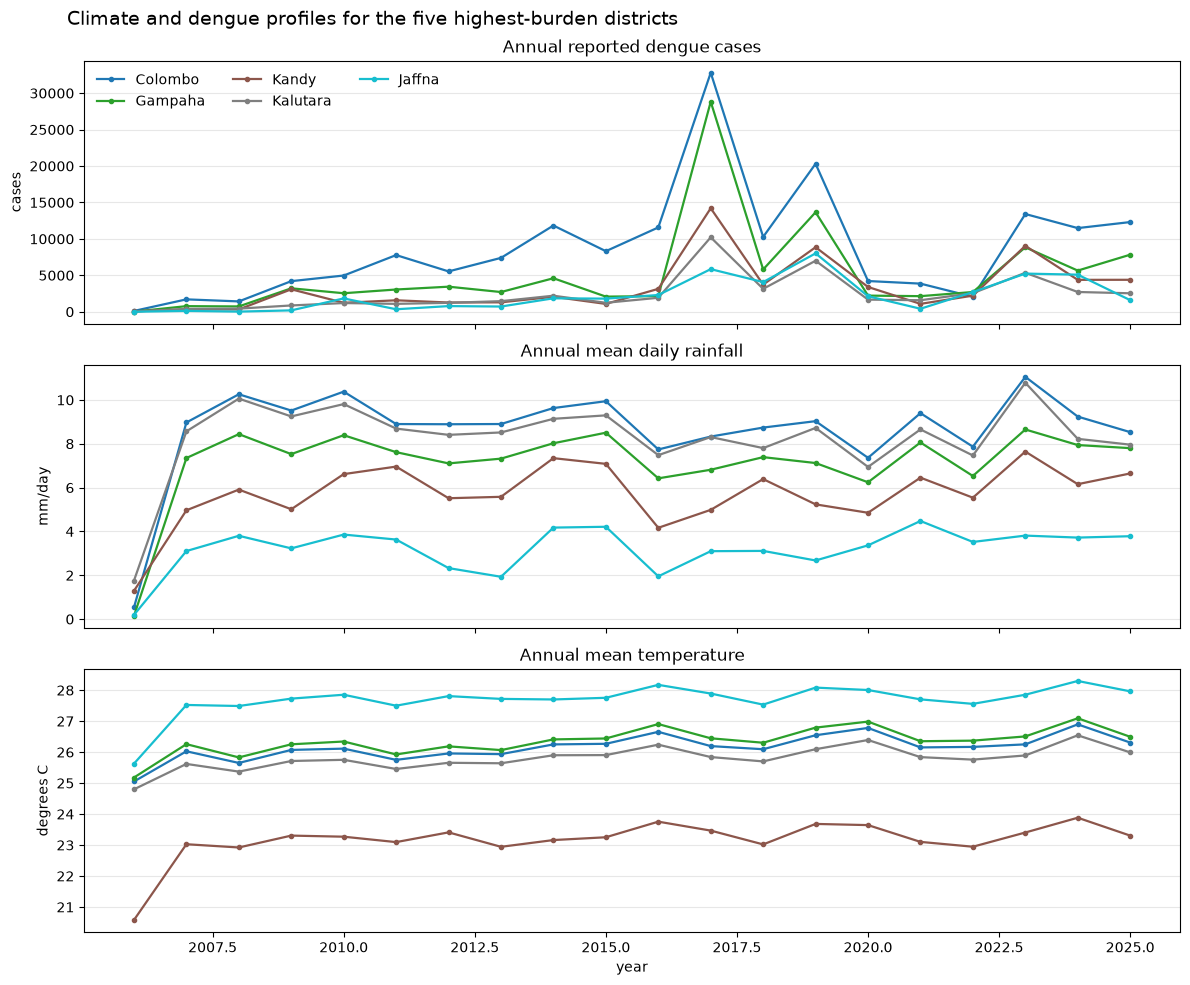

In [3]:
def weighted_mean(group, value):
    weights = group['reporting_days']
    return np.average(group[value], weights=weights)

annual = (
    top5_eda.groupby(['canonical_name', 'year'], as_index=False)
    .agg(cases=('cases', 'sum'),
         rainfall_mm_day=('rainfall_daily_mean_mm', lambda x: np.average(x, weights=top5_eda.loc[x.index, 'reporting_days'])),
         temperature_c=('temperature_mean_c', lambda x: np.average(x, weights=top5_eda.loc[x.index, 'reporting_days'])),
         humidity_pct=('relative_humidity_mean', lambda x: np.average(x, weights=top5_eda.loc[x.index, 'reporting_days'])))
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))
for color, district in zip(colors, top5):
    part = annual[annual['canonical_name'].eq(district)]
    axes[0].plot(part.year, part.cases, marker='o', ms=3, lw=1.6, color=color, label=district)
    axes[1].plot(part.year, part.rainfall_mm_day, marker='o', ms=3, lw=1.6, color=color)
    axes[2].plot(part.year, part.temperature_c, marker='o', ms=3, lw=1.6, color=color)

axes[0].set_title('Annual reported dengue cases')
axes[0].set_ylabel('cases')
axes[1].set_title('Annual mean daily rainfall')
axes[1].set_ylabel('mm/day')
axes[2].set_title('Annual mean temperature')
axes[2].set_ylabel('degrees C')
axes[2].set_xlabel('year')
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
axes[0].legend(ncol=3, loc='upper left', frameon=False)
fig.suptitle('Climate and dengue profiles for the five highest-burden districts', x=0.06, ha='left', fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR / 'fig6_top5_annual_climate_dengue.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Monthly seasonality by district

Standardised values make the timing easier to compare despite large differences in district case totals and climate levels. A value of 0 is that district's monthly mean; positive values are above its own average.

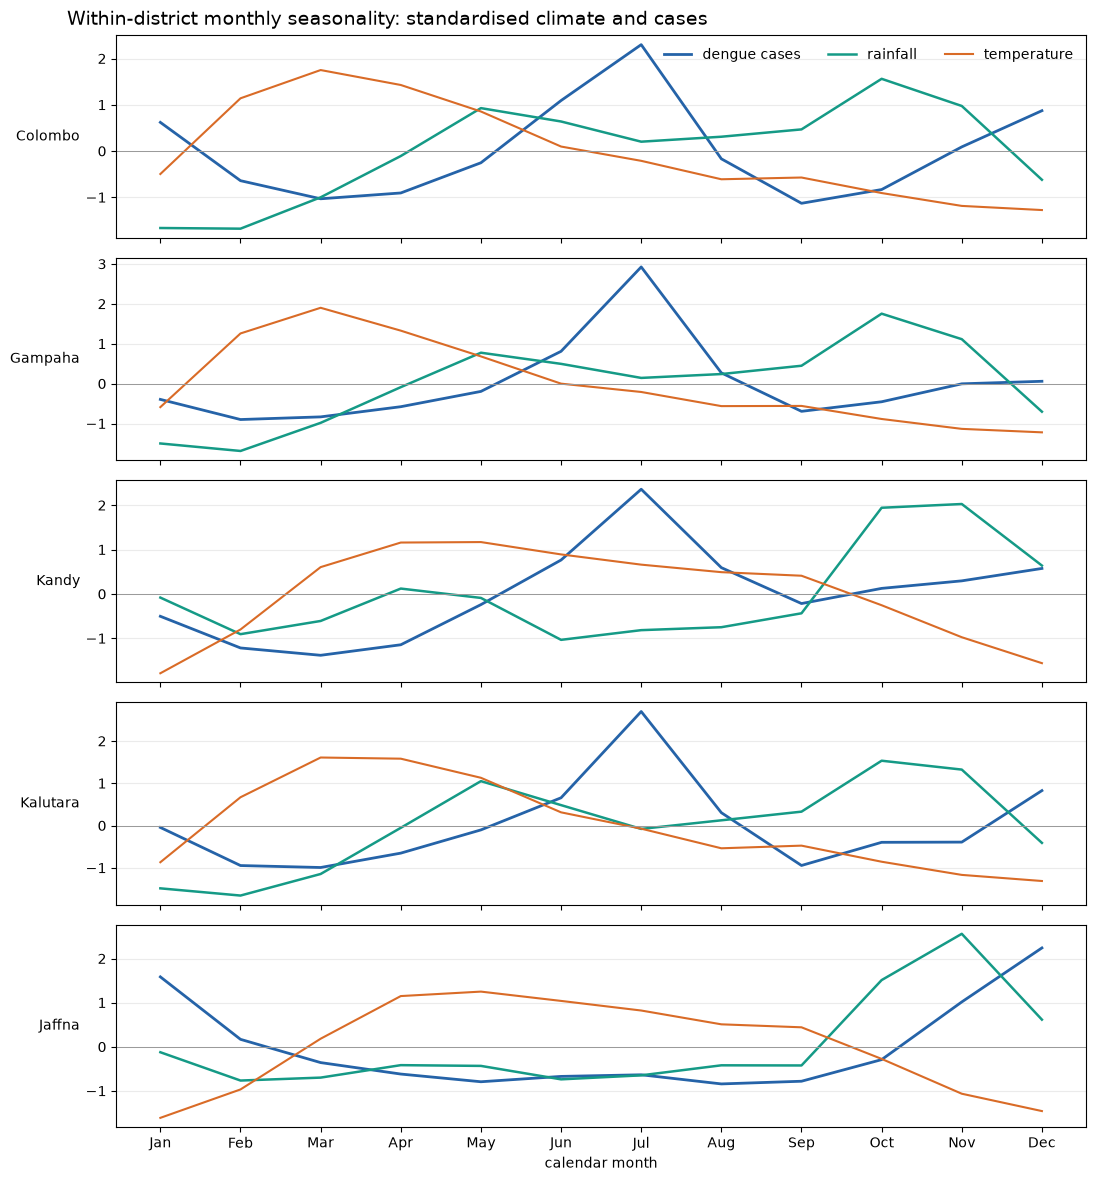

In [4]:
monthly = (
    top5_eda.groupby(['canonical_name', 'month'], as_index=False)
    .agg(cases=('cases', 'sum'),
         rainfall_mm_day=('rainfall_daily_mean_mm', 'mean'),
         temperature_c=('temperature_mean_c', 'mean'))
)
for column in ['cases', 'rainfall_mm_day', 'temperature_c']:
    monthly[f'{column}_z'] = monthly.groupby('canonical_name')[column].transform(
        lambda values: (values - values.mean()) / values.std(ddof=0)
    )

fig, axes = plt.subplots(len(top5), 1, figsize=(11, 12), sharex=True)
for ax, district in zip(axes, top5):
    part = monthly[monthly['canonical_name'].eq(district)]
    ax.plot(part.month, part.cases_z, color='#2563a8', lw=2, label='dengue cases')
    ax.plot(part.month, part.rainfall_mm_day_z, color='#159a86', lw=1.8, label='rainfall')
    ax.plot(part.month, part.temperature_c_z, color='#d96b27', lw=1.5, label='temperature')
    ax.axhline(0, color='#999999', lw=0.7)
    ax.set_ylabel(district, rotation=0, ha='right', va='center')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
axes[0].legend(ncol=3, frameon=False, loc='upper right')
axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[-1].set_xlabel('calendar month')
fig.suptitle('Within-district monthly seasonality: standardised climate and cases', x=0.06, ha='left', fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR / 'fig7_top5_monthly_seasonality.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Climate-case association and simple lag scan

The scatterplots show annual rainfall and temperature against annual cases. The table then calculates Pearson correlations between current cases and climate from 0-12 earlier reporting periods. Correlation is calculated within each district and should be read as a screening result, not a forecast or causal effect.

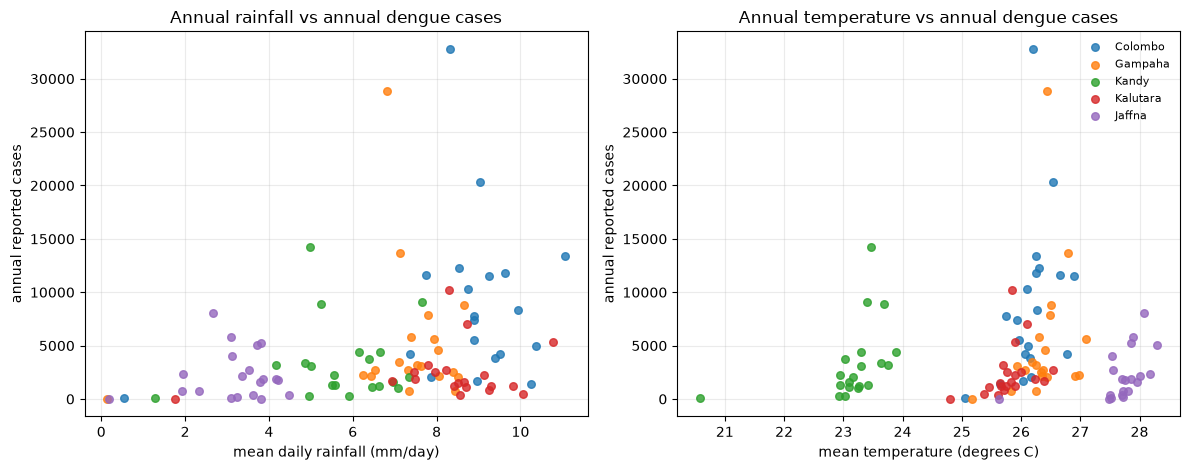

district,Colombo,Gampaha,Jaffna,Kalutara,Kandy
lag_periods,,,,,
0,-0.02,-0.00,0.07,-0.00,-0.01
1,-0.01,0.01,0.09,0.03,-0.01
2,0.01,0.02,0.12,0.02,0.01
3,0.04,0.02,0.15,0.04,0.00
4,0.09,0.04,0.20,0.04,0.02
5,0.13,0.06,0.21,0.08,0.03
6,0.13,0.06,0.23,0.08,0.03
7,0.13,0.06,0.23,0.10,0.04
8,0.12,0.05,0.21,0.06,0.04


,district,climate_variable,lag_periods,correlation
0,Colombo,rainfall_daily_mean_mm,5,0.13
1,Colombo,temperature_mean_c,12,0.11
2,Colombo,relative_humidity_mean,7,0.17
3,Gampaha,rainfall_daily_mean_mm,7,0.06
4,Gampaha,temperature_mean_c,12,0.14
5,Gampaha,relative_humidity_mean,6,0.11
6,Jaffna,rainfall_daily_mean_mm,6,0.23
7,Jaffna,temperature_mean_c,1,-0.24
8,Jaffna,relative_humidity_mean,6,0.30
9,Kalutara,rainfall_daily_mean_mm,7,0.10


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for district in top5:
    part = annual[annual['canonical_name'].eq(district)]
    axes[0].scatter(part.rainfall_mm_day, part.cases, s=30, alpha=0.8, label=district)
    axes[1].scatter(part.temperature_c, part.cases, s=30, alpha=0.8, label=district)
axes[0].set_title('Annual rainfall vs annual dengue cases')
axes[0].set_xlabel('mean daily rainfall (mm/day)')
axes[1].set_title('Annual temperature vs annual dengue cases')
axes[1].set_xlabel('mean temperature (degrees C)')
for ax in axes:
    ax.set_ylabel('annual reported cases')
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / 'fig8_annual_climate_case_association.png', dpi=200, bbox_inches='tight')
plt.show()

lag_rows = []
lagged = top5_eda.sort_values(['canonical_name', 'start_date']).copy()
for district, group in lagged.groupby('canonical_name'):
    group = group.set_index('start_date')
    for lag in range(13):
        row = {'district': district, 'lag_periods': lag}
        for climate_column in ['rainfall_daily_mean_mm', 'temperature_mean_c', 'relative_humidity_mean']:
            row[climate_column] = group['cases'].corr(group[climate_column].shift(lag))
        lag_rows.append(row)

lag_correlations = pd.DataFrame(lag_rows)
display(lag_correlations.pivot(index='lag_periods', columns='district', values='rainfall_daily_mean_mm').round(2))

best_lags = []
for district, group in lag_correlations.groupby('district'):
    for climate_column in ['rainfall_daily_mean_mm', 'temperature_mean_c', 'relative_humidity_mean']:
        best = group.loc[group[climate_column].abs().idxmax()]
        best_lags.append({
            'district': district,
            'climate_variable': climate_column,
            'lag_periods': int(best['lag_periods']),
            'correlation': best[climate_column],
        })
display(pd.DataFrame(best_lags).style.format({'correlation': '{:.2f}'}))

## Reading the result

Look for repeated patterns across districts and years, not a single large correlation. A useful follow-up is to repeat the comparison with population-adjusted incidence, explicit seasonal controls, and outbreak/reporting-quality indicators. The descriptive plots here are intentionally not used to fit or evaluate the forecasting model.